In [2]:
def neural_network(input, weights):
    out = 0
    for i in range(len(input)):
        out += (input[i] * weights[i])
    return out

def ele_mul(scalar, vector):
    out = [0,0,0]
    for i in range(len(out)):
        out[i] = scalar * vector[i]
    return out

toes = [8.5, 9.5, 9.9, 9.0]
wlrec = [0.65, 0.8, 0.8, 0.9]
nfans = [1.2, 1.3, 0.5, 1.0]

win_or_lose_binary = [1, 1, 0, 1]
truth = win_or_lose_binary[0]

alpha = 0.3
weights = [0.1, 0.2, -0.1]
input = [toes[0], wlrec[0], nfans[0]]

for iter in range(3):
    pred = neural_network(input, weights)
    error = (pred - truth) ** 2
    delta = pred - truth
    weight_deltas = ele_mul(delta, input)

    weight_deltas[0] = 0 # frozen weight

    print("Iteration:" + str(iter+1))
    print("Predicted:" + str(pred))
    print("Error:" + str(error))
    print("Delta:" + str(delta))
    print("Weights:" + str(weights))
    print("Weight Deltas:" + str(weight_deltas))
    print("")

    for i in range(len(weights)):
        weights[i] -= alpha * weight_deltas[i]

Iteration:1
Predicted:0.8600000000000001
Error:0.01959999999999997
Delta:-0.1399999999999999
Weights:[0.1, 0.2, -0.1]
Weight Deltas:[0, -0.09099999999999994, -0.16799999999999987]

Iteration:2
Predicted:0.9382250000000001
Error:0.003816150624999989
Delta:-0.06177499999999991
Weights:[0.1, 0.2273, -0.04960000000000005]
Weight Deltas:[0, -0.040153749999999946, -0.07412999999999989]

Iteration:3
Predicted:0.97274178125
Error:0.000743010489422852
Delta:-0.027258218750000007
Weights:[0.1, 0.239346125, -0.02736100000000008]
Weight Deltas:[0, -0.017717842187500006, -0.032709862500000006]



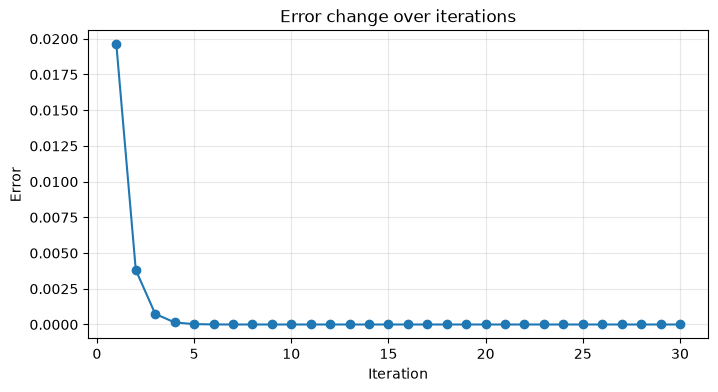

In [6]:
# errorの推移を記録して可視化（既存のweightsは上書きしない）
n_steps = 30
sim_weights = [0.1, 0.2, -0.1]
error_history = []

for step in range(n_steps):
    sim_pred = neural_network(input, sim_weights)
    sim_error = (sim_pred - truth) ** 2
    error_history.append(sim_error)

    sim_delta = sim_pred - truth
    sim_weight_deltas = ele_mul(sim_delta, input)
    sim_weight_deltas[0] = 0  # frozen weight

    for j in range(len(sim_weights)):
        sim_weights[j] -= alpha * sim_weight_deltas[j]

plt.figure(figsize=(8, 4))
plt.plot(range(1, n_steps + 1), error_history, marker="o")
plt.title("Error change over iterations")
plt.xlabel("Iteration")
plt.ylabel("Error")
plt.grid(True, alpha=0.3)
plt.show()